In [3]:
import scanpy as sc
from glob import glob
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [47]:
adata=sc.read("data/Wu2021/CID4535.h5ad")

In [48]:
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

In [49]:
adata

AnnData object with n_obs × n_vars = 1127 × 19237
    obs: 'in_tissue', 'array_row', 'array_col', 'subtype', 'pathology', 'sample', 'replicate', 'source', 'ER', 'HER2', 'PR'
    uns: 'spatial', 'log1p'
    obsm: 'celltype_major', 'celltype_minor', 'spatial'
    layers: 'raw_counts'

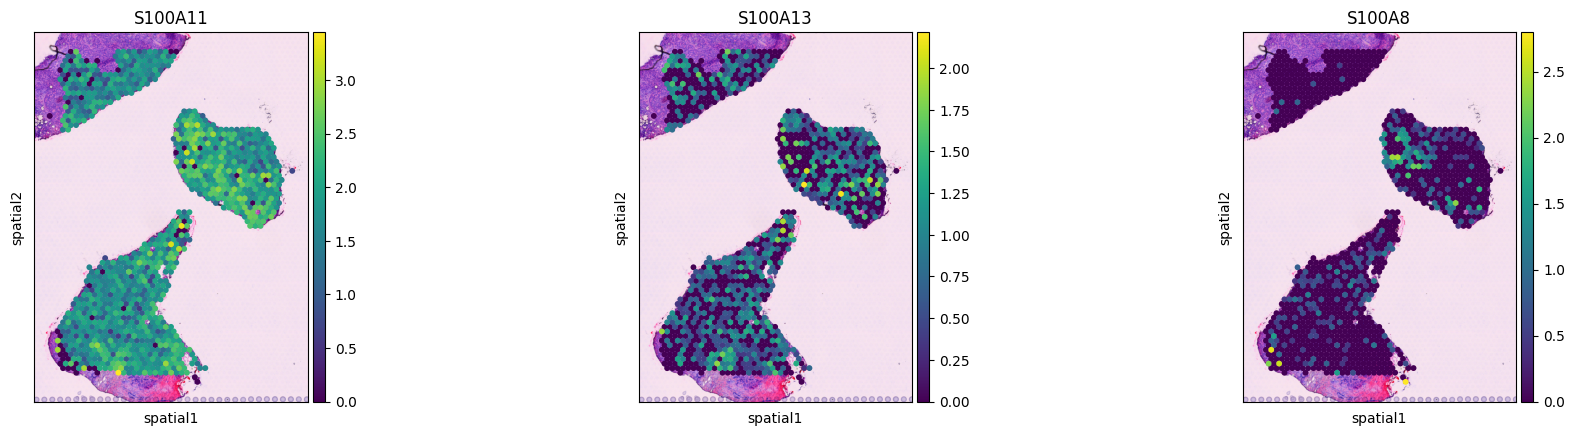

In [50]:
sc.pl.spatial(adata, color=["S100A11", "S100A13", "S100A8"], size=1.7)

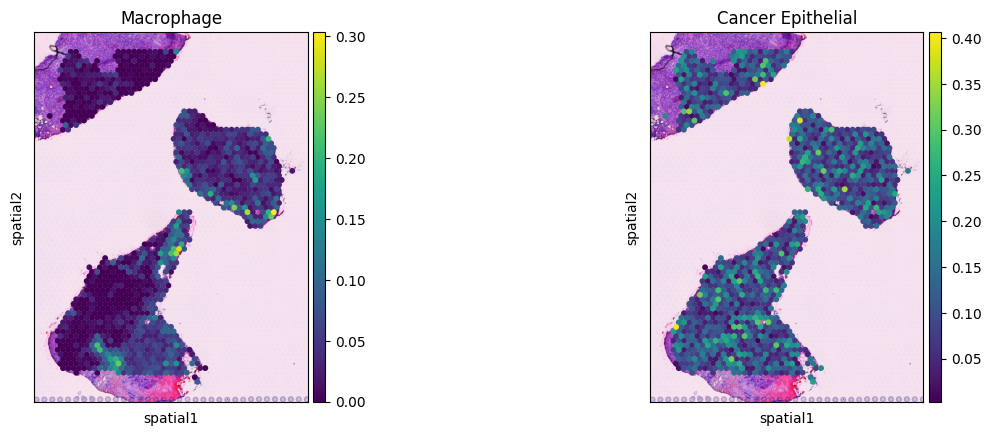

In [51]:
adata.obs['Cancer Epithelial']=adata.obsm['celltype_major']['Cancer Epithelial']
adata.obs['Normal Epithelial']=adata.obsm['celltype_major']['Normal Epithelial']
adata.obs['Epithelial']=adata.obsm['celltype_major']['Normal Epithelial']+adata.obsm['celltype_major']['Cancer Epithelial']

adata.obs['Macrophage']=adata.obsm['celltype_minor']['Macrophage']

sc.pl.spatial(adata, color=["Macrophage", "Cancer Epithelial"], size=1.7)

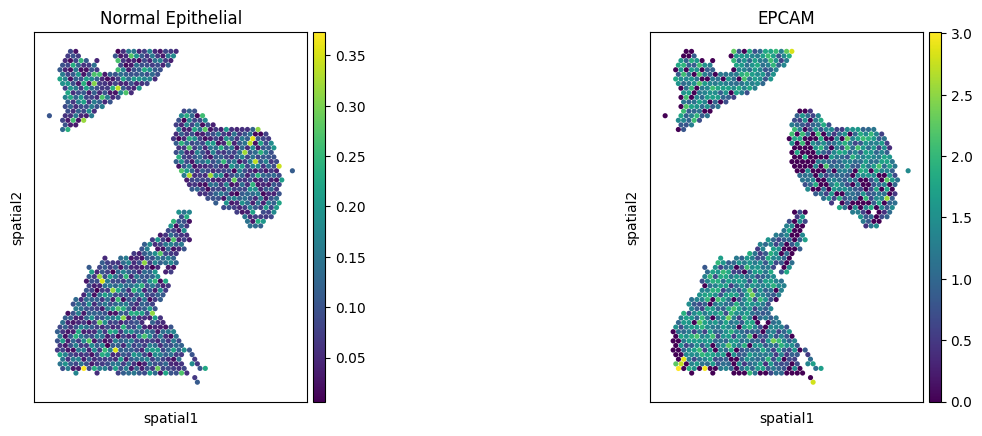

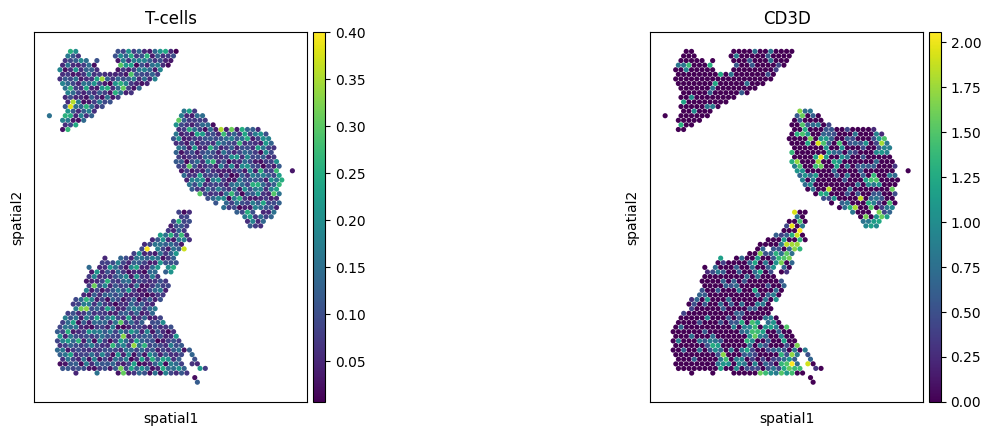

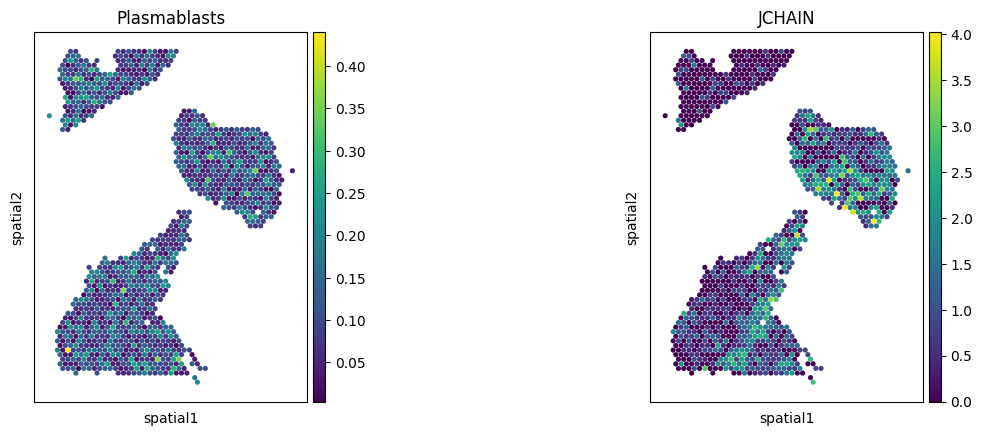

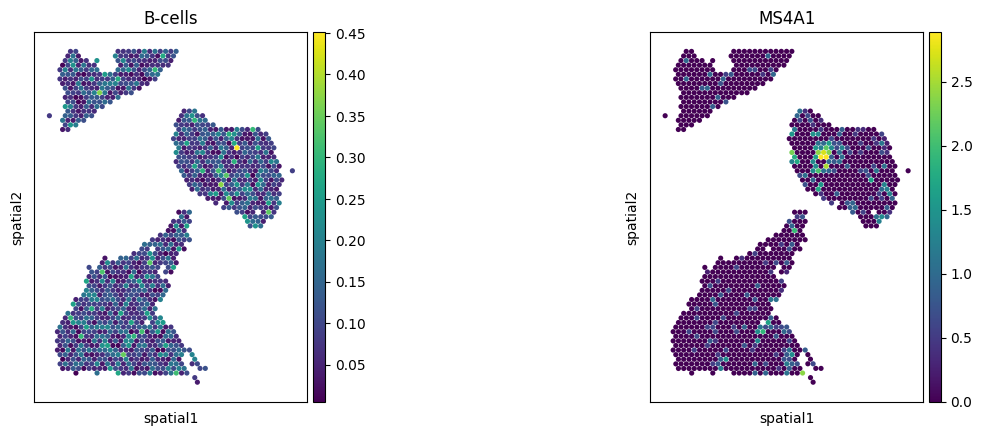

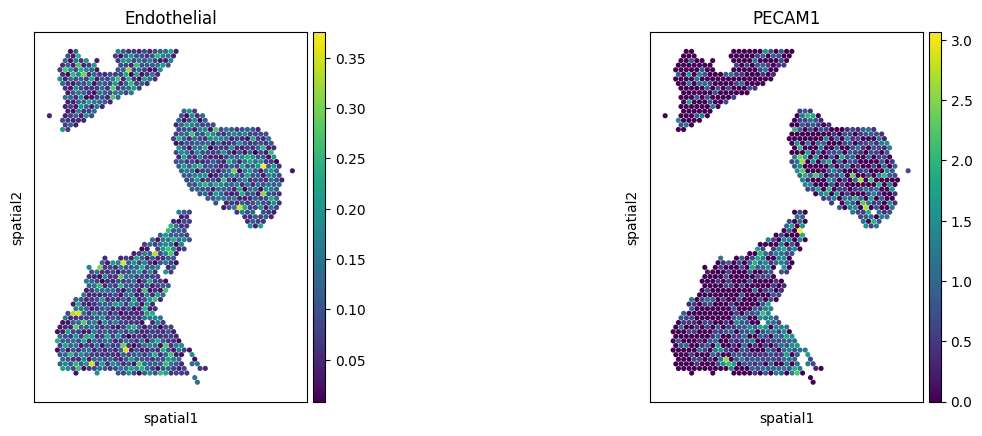

In [52]:
import squidpy
sc.pl.spatial(squidpy.pl.extract(adata, "celltype_major"),
              color=["Normal Epithelial", "EPCAM"],
              alpha_img=0, size=1.5)

sc.pl.spatial(squidpy.pl.extract(adata, "celltype_major"),
              color=["T-cells", "CD3D"],
              alpha_img=0, size=1.5)

sc.pl.spatial(squidpy.pl.extract(adata, "celltype_major"),
              color=["Plasmablasts", "JCHAIN"],
              alpha_img=0, size=1.5)
sc.pl.spatial(squidpy.pl.extract(adata, "celltype_major"),
              color=["B-cells", "MS4A1"],
              alpha_img=0, size=1.5)
sc.pl.spatial(squidpy.pl.extract(adata, "celltype_major"),
              color=["Endothelial", "PECAM1"],
              alpha_img=0, size=1.5)

In [ ]:
sc.pl.spatial(adata, color=["S100A11", "S100A13", "S100A8"], size=1.7)

In [9]:
[x for x in ["S100A11", "S100A13", "S100A8"] if x in adata.var_names]

['S100A11', 'S100A13', 'S100A8']

In [114]:
#sc.pl.spatial(adata, color=["S100A11", "S100A13", "S100A8"], size=2)

In [133]:
import pandas as pd
df=adata.to_df()[["S100A11", "S100A13", "S100A8"]].merge(adata.obsm['celltype_minor'][['Cancer Epithelial', 'Macrophages']], left_index=True, right_index=True)
df.columns=['S100A11', 'S100A13', 'S100A8', 'Cancer_Epithelial', 'Macrophages']
df['other_cells']=1-df['Cancer_Epithelial']-df['Macrophages']

In [138]:
mod = smf.ols(formula='S100A13 ~0+other_cells+Macrophages*Cancer_Epithelial', data=df)
res = mod.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                S100A13   R-squared:                       0.012
Model:                            OLS   Adj. R-squared:                  0.010
Method:                 Least Squares   F-statistic:                     7.018
Date:                Thu, 22 Dec 2022   Prob (F-statistic):           0.000109
Time:                        12:47:09   Log-Likelihood:                -730.64
No. Observations:                1712   AIC:                             1469.
Df Residuals:                    1708   BIC:                             1491.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
other_cells   

/Users/aprilsagan/opt/anaconda3/lib/python3.8/site-packages/scanpy/preprocessing/_normalization.py:170: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
<ipython-input-88-e07cabd356d8>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['celltype'].loc[cancer_epithelial]="cancer_epithelial"
<ipython-input-88-e07cabd356d8>:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['celltype'].loc[macrophages]="macrophages"


<AxesSubplot:xlabel='variable', ylabel='value'>

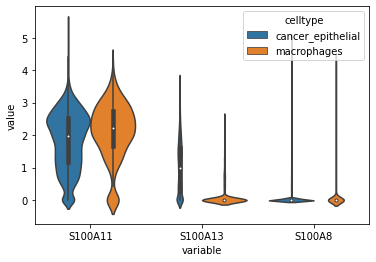

In [88]:
adata_sc=sc.read_h5ad("data/Wu2021/scRNA.h5ad")
adata_sc=adata_sc[adata_sc.obs.query("subtype=='ER+'").index]
sc.pp.normalize_total(adata_sc)
sc.pp.log1p(adata_sc)

macrophages=adata_sc.obs.query("celltype_minor=='Macrophage'").index
cancer_epithelial=adata_sc.obs.query("celltype_major=='Cancer Epithelial'").index

df=adata_sc.to_df().loc[[*cancer_epithelial,*macrophages],["S100A11", "S100A13", "S100A8"]]

df['celltype']=None
df['celltype'].loc[cancer_epithelial]="cancer_epithelial"
df['celltype'].loc[macrophages]="macrophages"
df=df.melt(id_vars='celltype')

sns.violinplot(data=df, x="variable", y="value", hue="celltype")

In [91]:
df['value_binary']=df['value']>0
df.groupby(["celltype","variable"]).mean()['value']

celltype           variable
cancer_epithelial  S100A11     1.837706
                   S100A13     0.999567
                   S100A8      0.038068
macrophages        S100A11     2.114451
                   S100A13     0.086764
                   S100A8      0.089395
Name: value, dtype: float32

In [69]:
adata_sc.obs.query("celltype_major=='Cancer Epithelial'")

,orig.ident,nCount_RNA,nFeature_RNA,percent.mito,subtype,celltype_subset,celltype_minor,celltype_major
CID3921_ACATCAGAGGGTGTTG,CID3921,52289,6552,5.398841,HER2+,Cancer Cycling,Cancer Cycling,Cancer Epithelial
CID3921_ACGATACCATTTGCCC,CID3921,4390,1389,5.261959,HER2+,Cancer Cycling,Cancer Cycling,Cancer Epithelial
CID3921_ACGCAGCTCCGCATCT,CID3921,61060,7151,3.974779,HER2+,Cancer Cycling,Cancer Cycling,Cancer Epithelial
CID3921_AGAGCTTGTCAAAGCG,CID3921,44059,5676,9.226265,HER2+,Cancer Cycling,Cancer Cycling,Cancer Epithelial
CID3921_AGAGTGGTCACTTCAT,CID3921,4110,1576,2.846715,HER2+,Cancer Cycling,Cancer Cycling,Cancer Epithelial
...,...,...,...,...,...,...,...,...
CID4290A_TTGCCGTAGTCGATAA,CID4290A,8926,2165,15.617298,ER+,Cancer Her2 SC,Cancer Her2 SC,Cancer Epithelial
CID4290A_TTGGCAAAGAGTACAT,CID4290A,3254,1226,11.954518,ER+,Cancer Her2 SC,Cancer Her2 SC,Cancer Epithelial
CID4290A_TTGGCAACAATGGAAT,CID4290A,9117,2433,11.056269,ER+,Cancer Her2 SC,Cancer Her2 SC,Cancer Epithelial
CID4290A_TTTACTGTCCGAGCCA,CID4290A,1410,641,10.212766,ER+,Cancer Her2 SC,Cancer Her2 SC,Cancer Epithelial
